In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [118]:
import numpy as np

from src.utils import paths
from src.utils.helpers import get_dataframe

import pandas as pd

from matplotlib import pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler

import joblib

In [3]:
cwd = os.getcwd()
print(f'cwd = {cwd}')
cwd += '/../'

cwd = D:\venv\src\lg18650hg2\notebooks


In [95]:
features = ['V', 'I', 'Temp', 'V_avg', 'I_avg']
targets = ['SOC']

train_raw_data_dir = os.path.join(cwd, paths.train_raw_data_dir)
val_raw_data_dir = os.path.join(cwd, paths.val_raw_data_dir)
test_raw_data_dir = os.path.join(cwd, paths.test_raw_data_dir)

train_raw_data_list_dir = os.listdir(train_raw_data_dir)
val_raw_data_list_dir = os.listdir(val_raw_data_dir)
test_raw_data_list_dir = os.listdir(test_raw_data_dir)

print(f'train_raw_data_list_dir = {train_raw_data_list_dir}')
print(f'train_raw_data_list_dir = {val_raw_data_list_dir}')
print(f'train_raw_data_list_dir = {test_raw_data_list_dir}')

train_raw_data_list_dir = ['TRAIN_LGHG2@n10degC_to_25degC_Norm_5Inputs.csv']
train_raw_data_list_dir = ['01_TEST_LGHG2@n10degC_Norm_(05_Inputs).csv']
train_raw_data_list_dir = ['02_TEST_LGHG2@0degC_Norm_(05_Inputs).csv', '03_TEST_LGHG2@10degC_Norm_(05_Inputs).csv', '04_TEST_LGHG2@25degC_Norm_(05_Inputs).csv']


In [96]:
train_raw_data = get_dataframe(dir_path=train_raw_data_dir, listdir=train_raw_data_list_dir)
val_raw_data = get_dataframe(dir_path=val_raw_data_dir, listdir=val_raw_data_list_dir)
test_raw_data = get_dataframe(dir_path=test_raw_data_dir, listdir=test_raw_data_list_dir)

In [6]:
train_raw_features = train_raw_data[features].to_numpy()
train_raw_targets = train_raw_data[targets].to_numpy()

val_raw_features = val_raw_data[features].to_numpy()
val_raw_targets = val_raw_data[targets].to_numpy()

test_raw_features = test_raw_data[features].to_numpy()
test_raw_targets = test_raw_data[targets].to_numpy()

In [8]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42, verbose=1)
rfr.fit(train_raw_features, train_raw_targets.ravel())

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  4.6min finished


RandomForestRegressor(random_state=42, verbose=1)

In [120]:
importances = rfr.feature_importances_
importances_dict = list(zip(features, importances))
importances_dict = sorted(importances_dict, key=lambda x:x[1], reverse=True)
importances_ordered = list(map(lambda x:x[1], importances_dict))
features_ordered = list(map(lambda x:x[0], importances_dict))
importances_dict

[('V_avg', 0.9463796864016113),
 ('I_avg', 0.029168146984034717),
 ('Temp', 0.017075302472711544),
 ('V', 0.0065981088712919085),
 ('I', 0.0007787552703505623)]

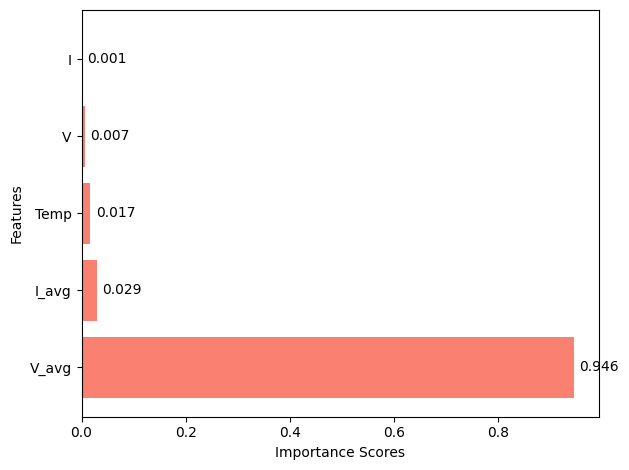

In [121]:
fig, ax = plt.subplots(1)
plt.barh(range(len(importances_dict)), importances_ordered, color="salmon", align='center')
plt.yticks(range(len(importances)), features_ordered)
plt.xlabel('Importance Scores')
plt.ylabel('Features')
for i, v in enumerate(importances_ordered):
    plt.text(v + 0.01, i, f"{v:.3f}", va='center', color='black')
plt.tight_layout()
plt.savefig(os.path.join(cwd, paths.importances_dir, 'feature_importance.png'), bbox_inches='tight',dpi=300)
plt.show()
plt.close()

In [84]:
threshold = 0.01
importances_dict = [item for item in importances_dict if item[1] >= threshold]
importances_dict

[('V_avg', 0.9463796864016113),
 ('I_avg', 0.029168146984034717),
 ('Temp', 0.017075302472711544)]

In [97]:
features_non_redundant = [item[0] for item in importances_dict]
importances_non_redundant = [item[1] for item in importances_dict]

train_raw_features = train_raw_data[features_non_redundant].to_numpy()
val_raw_features = val_raw_data[features_non_redundant].to_numpy()
test_raw_features = test_raw_data[features_non_redundant].to_numpy()

In [105]:
scaler = MinMaxScaler(feature_range=(-1,1))
train_scaled_features = scaler.fit_transform(train_raw_features)
val_scaled_features = scaler.transform(val_raw_features)
test_scaled_features = scaler.transform(test_raw_features)

In [111]:
def raw2ts(raw_features, raw_targets=None, window_length=1, shift=1):
    batch_size = (len(raw_features) - window_length) // shift + 1
    num_features = raw_features.shape[1]
    # initializing an empty 3D array for ts_features with the shape (batch_size, window_length, num_features)
    ts_features = np.empty((batch_size, window_length, num_features))
    if raw_targets is not None:
        ts_targets = np.empty(batch_size)
    for batch in range(batch_size):
        # getting the start and end indices for the current window of raw_features
        start_idx = batch * shift
        end_idx = start_idx + window_length
        ts_features[batch] = raw_features[start_idx:end_idx]
        if raw_targets is not None:
            ts_targets[batch] = raw_targets[end_idx - 1]
    if raw_targets is not None:
        return ts_features, ts_targets
    else:
        return ts_features

In [115]:
train_ts_features, train_ts_targets = raw2ts(train_scaled_features, train_raw_targets)
train_ts_features.shape, train_ts_targets.shape

((669956, 1, 3), (669956,))

In [116]:
val_ts_features, val_ts_targets = raw2ts(val_scaled_features, val_raw_targets)
val_ts_features.shape, val_ts_targets.shape

((39293, 1, 3), (39293,))

In [117]:
test_ts_features, test_ts_targets = raw2ts(test_scaled_features, test_raw_targets)
test_ts_features.shape, test_ts_targets.shape

((134331, 1, 3), (134331,))

In [123]:
rfr_path = os.path.join(cwd, paths.models_dir, 'rfr.pkl')
joblib.dump(rfr, rfr_path)

scaler_path = os.path.join(cwd, paths.models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)

train_ts_features_path = os.path.join(cwd, paths.processed_data_dir, 'train_ts_features.npy')
train_ts_targets_path = os.path.join(cwd, paths.processed_data_dir, 'train_ts_targets.npy')
np.save(train_ts_features_path, train_ts_features)
np.save(train_ts_targets_path, train_ts_targets)

val_ts_features_path = os.path.join(cwd, paths.processed_data_dir, 'val_ts_features.npy')
val_ts_targets_path = os.path.join(cwd, paths.processed_data_dir, 'val_ts_targets.npy')
np.save(val_ts_features_path, val_ts_features)
np.save(val_ts_targets_path, val_ts_targets)

test_ts_features_path = os.path.join(cwd, paths.processed_data_dir, 'test_ts_features.npy')
test_ts_targets_path = os.path.join(cwd, paths.processed_data_dir, 'test_ts_targets.npy')
np.save(test_ts_features_path, test_ts_features)
np.save(test_ts_targets_path, test_ts_targets)